# Credit Risk Prediction Project

## 1. Business Problem

Financial institutions face significant risk when issuing loans. The core challenge is to determine whether a loan applicant is likely to default.

The goal of this project is to build a machine learning model that predicts the probability of a customer defaulting on a loan.



## 2. Objective

To develop a classification model that helps lenders decide:

- Whether to approve or reject a loan application
- Minimize financial losses due to defaults



## 3. Stakeholder

- Banks
- Microfinance institutions
- Fintech lending platforms



## 4. Target Variable

The target variable represents whether a customer defaults:

- `1` → Default (High Risk)
- `0` → No Default (Low Risk)



## 5. Business Impact

Types of errors:

- False Negative (Worst Case):
  Approving a customer who defaults → Financial loss

- False Positive:
  Rejecting a good customer → Lost revenue opportunity

The model should prioritize reducing False Negatives.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv(r'../data/credit_risk_dataset.csv')
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [3]:
#shape of the dataset
print(df.shape)

#name of columns
print(df.columns)

#data types
print(df.info)

(32581, 12)
Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')
<bound method DataFrame.info of        person_age  person_income person_home_ownership  person_emp_length  \
0              22          59000                  RENT              123.0   
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE  

In [4]:
# Missing values
df.isnull().sum().sort_values(ascending=False)

loan_int_rate                 3116
person_emp_length              895
person_income                    0
person_age                       0
person_home_ownership            0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [5]:
# check tagfet distribution
df['loan_status'].value_counts(normalize=True)

loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64

In [6]:
# summary statistics
df.describe

<bound method NDFrame.describe of        person_age  person_income person_home_ownership  person_emp_length  \
0              22          59000                  RENT              123.0   
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE                4.0   
32578          65          76000                  RENT                3.0   
32579          56         150000              MORTGAGE                5.0   
32580          66          42000                  RENT                2.0   

           loan_intent loan_grade  loan_a

## Data Understanding Summary

### Dataset Overview
- Number of rows: 32,581
- Number of features: 12



### Target Variable
- `loan_status`
    - 0 → No Default
    - 1 → Default


### Class Distribution
- 78% Non-default
- 22% Default

This indicates moderate class imbalance.



### Missing Values
- `loan_int_rate`: ~10% missing
- `person_emp_length`: missing values present


### Potential Data Leakage
Some variables may contain post-decision information:

- `loan_int_rate`
- `loan_percent_income`

These may need to be excluded or carefully evaluated.

In [7]:
print(df['loan_percent_income'].describe())

df[['loan_amnt', 'person_income', 'loan_percent_income']].head(10)

count    32581.000000
mean         0.170203
std          0.106782
min          0.000000
25%          0.090000
50%          0.150000
75%          0.230000
max          0.830000
Name: loan_percent_income, dtype: float64


,loan_amnt,person_income,loan_percent_income
0,35000,59000,0.59
1,1000,9600,0.10
2,5500,9600,0.57
3,35000,65500,0.53
4,35000,54400,0.55
5,2500,9900,0.25
6,35000,77100,0.45
7,35000,78956,0.44
8,35000,83000,0.42
9,1600,10000,0.16


Its evident that loan_percent_income = loan_amnt / person_income
Loan percent income is not an indipenedent feature and therefore will be dropped for feature engineering

In [8]:
df_clean = df.copy()

# Drop derived feature
df_clean = df_clean.drop(columns=['loan_percent_income'])

df_clean.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,Y,4


In [9]:
# Fill missing values
df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median(), inplace=True)
df_clean['loan_int_rate'].fillna(df_clean['loan_int_rate'].median(), inplace=True)

# Confirm
df_clean.isnull().sum()

C:\Users\User\AppData\Local\Temp\ipykernel_22300\480707303.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['person_emp_length'].fillna(df_clean['person_emp_length'].median(), inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_22300\480707303.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

# EDA

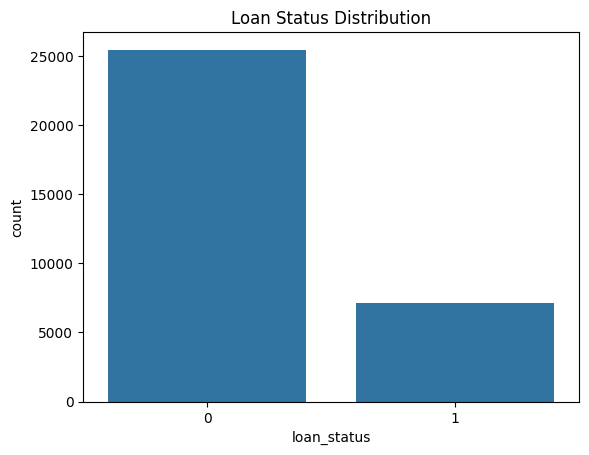

In [10]:

# target distribution
sns.countplot(x='loan_status', data=df)
plt.title("Loan Status Distribution")
plt.show()

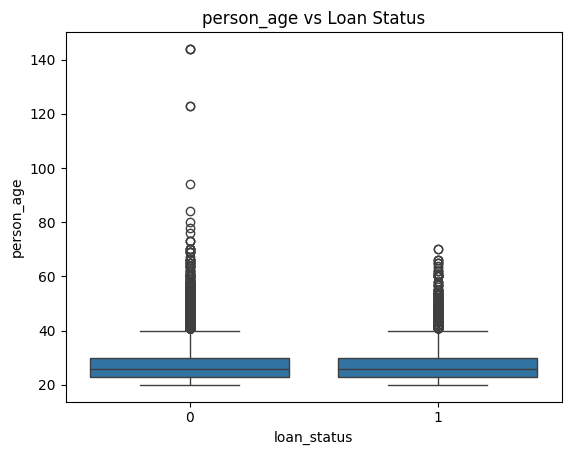

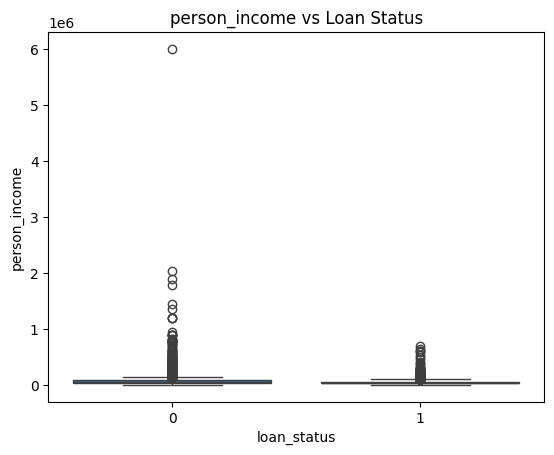

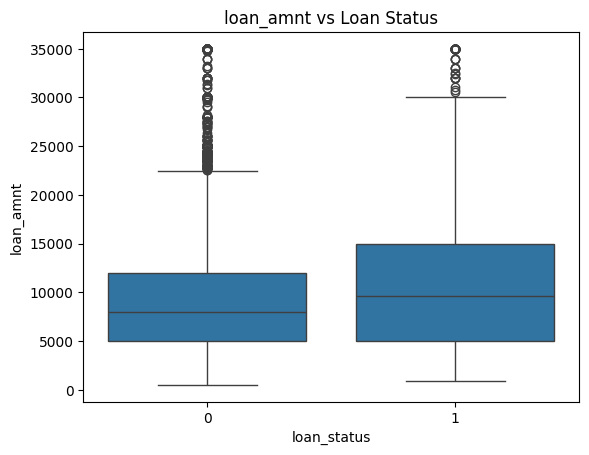

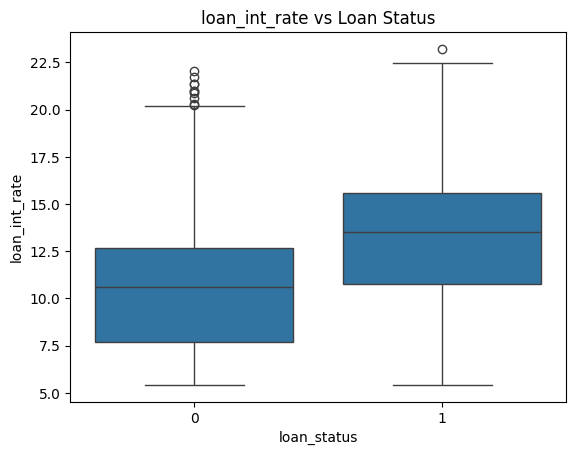

In [11]:
# Numerical Features vs Targets
num_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate']

for col in num_cols:
    plt.figure()
    sns.boxplot(x='loan_status', y=col, data=df)
    plt.title(f"{col} vs Loan Status")
    plt.show()

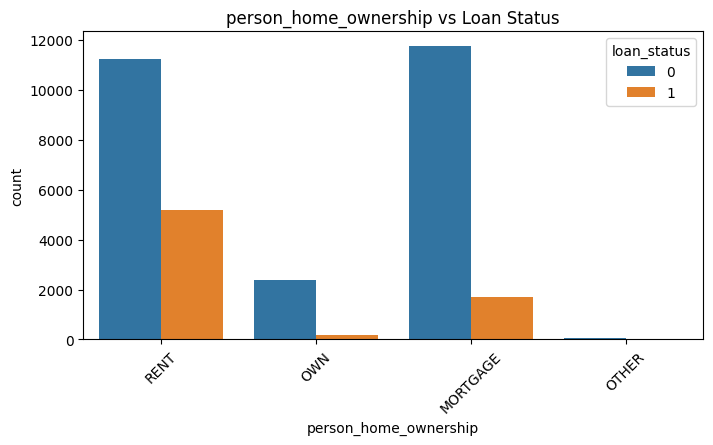

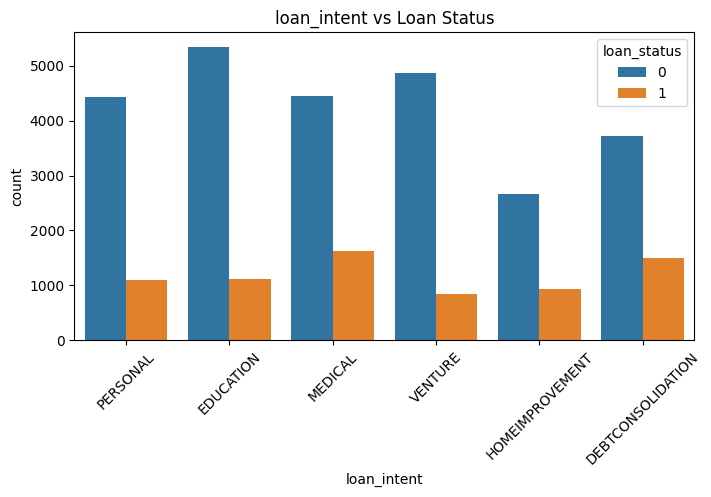

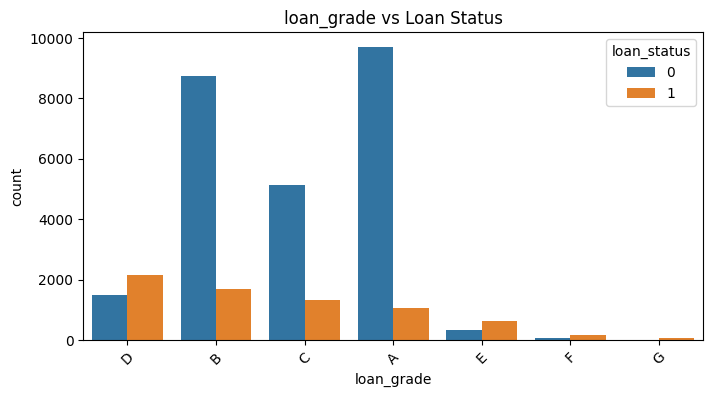

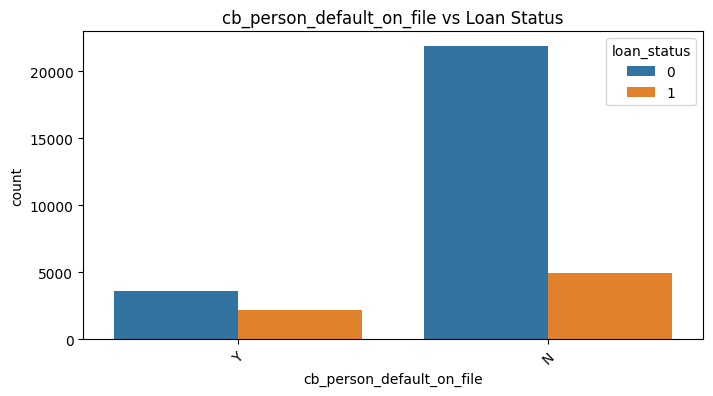

In [12]:
# Categorical features Vs target
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='loan_status', data=df)
    plt.title(f"{col} vs Loan Status")
    plt.xticks(rotation=45)
    plt.show()

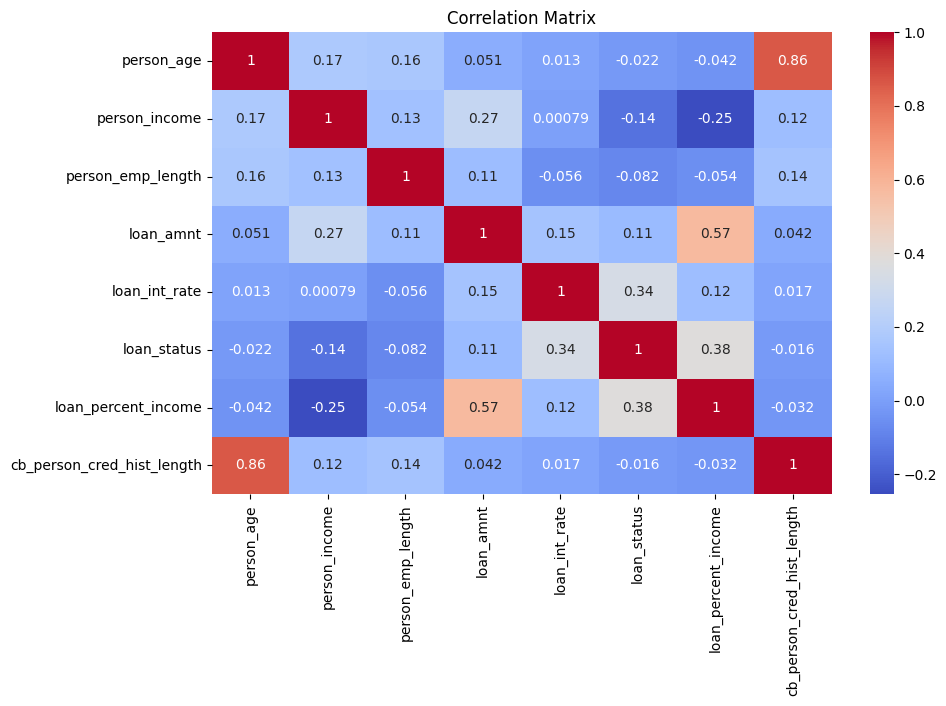

In [13]:
# Correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## Key Insights from EDA

### 1. Strong Predictors
- Loan grade is highly indicative of default risk
- Interest rate shows strong correlation with default (possible leakage)



### 2. Moderate Predictors
- Loan amount has some influence on default
- Loan intent may influence risk but needs further validation


### 3. Weak Predictors
- Income shows weak negative correlation with default
- Employment length has minimal impact



### 4. Feature Relationships
- Age and credit history length are highly correlated (0.86)
- Indicates possible redundancy



### 5. Risk Indicators
- Higher loan burden relative to income increases default likelihood
- Certain home ownership statuses correlate with higher risk

In [14]:
# Default rate by loan intent
df.groupby('loan_intent')['loan_status'].mean().sort_values(ascending=False)



loan_intent
DEBTCONSOLIDATION    0.285879
MEDICAL              0.267007
HOMEIMPROVEMENT      0.261026
PERSONAL             0.198877
EDUCATION            0.172168
VENTURE              0.148103
Name: loan_status, dtype: float64

In [15]:
# Default rate by home ownership
df.groupby('person_home_ownership')['loan_status'].mean().sort_values(ascending=False)



person_home_ownership
RENT        0.315700
OTHER       0.308411
MORTGAGE    0.125707
OWN         0.074690
Name: loan_status, dtype: float64

In [16]:
# Default rate by loan grade
df.groupby('loan_grade')['loan_status'].mean().sort_values(ascending=False)

loan_grade
G    0.984375
F    0.705394
E    0.644191
D    0.590458
C    0.207340
B    0.162760
A    0.099564
Name: loan_status, dtype: float64

## Final EDA Insights

### Loan Intent
- Debt consolidation loans have the highest default rate (~28.6%)
- Venture loans have the lowest (~14.8%)
- Indicates financial stress vs planned investment behavior

---

### Home Ownership
- Renters show significantly higher default rates (~31.6%)
- Homeowners have the lowest (~7.5%)
- Strong indicator of financial stability

---

### Loan Grade
- Extremely strong predictor of default
- Default rates increase sharply from Grade A (9.9%) to G (98%)

Note:
Loan grade may be derived from internal risk assessment → potential data leakage

# Feature engineering

In [17]:
df_fe = df.copy()

# Drop leakage + redundant features
df_fe = df_fe.drop(columns=[
    'loan_grade',
    'loan_int_rate',
    'loan_percent_income',
    'person_age'
])

df_fe.head()

,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_status,cb_person_default_on_file,cb_person_cred_hist_length
0,59000,RENT,123.0,PERSONAL,35000,1,Y,3
1,9600,OWN,5.0,EDUCATION,1000,0,N,2
2,9600,MORTGAGE,1.0,MEDICAL,5500,1,N,3
3,65500,RENT,4.0,MEDICAL,35000,1,N,2
4,54400,RENT,8.0,MEDICAL,35000,1,Y,4


#### Create better features

In [18]:
# Debt to income ratio
df_fe['debt_to_income'] = df_fe['loan_amnt'] / df_fe['person_income']

In [19]:
# Income backets
df_fe['income_group'] = pd.qcut(df_fe['person_income'], q=4, labels=['low', 'mid', 'high', 'very_high'])

In [20]:
# bEmployment length backets
df_fe['emp_length_group'] = pd.cut(
    df_fe['person_emp_length'],
    bins=[0, 2, 5, 10, 50],
    labels=['new', 'junior', 'mid', 'senior']
)

In [21]:
# Credit experence ratio
df_fe['credit_exp_ratio'] = df_fe['cb_person_cred_hist_length'] / (df_fe['person_emp_length'] + 1)

#### Encode categorical variables

In [22]:
df_fe = pd.get_dummies(df_fe, drop_first=True)

In [23]:
from sklearn.model_selection import train_test_split

X = df_fe.drop('loan_status', axis=1)
y = df_fe['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
print(df_fe.head())
print((df_fe.columns))
print(X_train.shape)

   person_income  person_emp_length  loan_amnt  loan_status  \
0          59000              123.0      35000            1   
1           9600                5.0       1000            0   
2           9600                1.0       5500            1   
3          65500                4.0      35000            1   
4          54400                8.0      35000            1   

   cb_person_cred_hist_length  debt_to_income  credit_exp_ratio  \
0                           3        0.593220          0.024194   
1                           2        0.104167          0.333333   
2                           3        0.572917          1.500000   
3                           2        0.534351          0.400000   
4                           4        0.643382          0.444444   

   person_home_ownership_OTHER  person_home_ownership_OWN  \
0                        False                      False   
1                        False                       True   
2                        False     

We consider dropping person_emp_lenght beacause we already created emp_length_group 

Thats dublicate infomation

In [25]:
df_fe = df_fe.drop(columns=['person_emp_length'])

# Modelling

In [26]:
# future scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Baseline model

In [27]:
import numpy as np

# Check for NaNs
print("NaNs per column:\n", X_train.isnull().sum())

# Check for infinite values
print("Infinite values:\n", np.isinf(X_train).sum())

NaNs per column:
 person_income                    0
person_emp_length              738
loan_amnt                        0
cb_person_cred_hist_length       0
debt_to_income                   0
credit_exp_ratio               738
person_home_ownership_OTHER      0
person_home_ownership_OWN        0
person_home_ownership_RENT       0
loan_intent_EDUCATION            0
loan_intent_HOMEIMPROVEMENT      0
loan_intent_MEDICAL              0
loan_intent_PERSONAL             0
loan_intent_VENTURE              0
cb_person_default_on_file_Y      0
income_group_mid                 0
income_group_high                0
income_group_very_high           0
emp_length_group_junior          0
emp_length_group_mid             0
emp_length_group_senior          0
dtype: int64
Infinite values:
 person_income                  0
person_emp_length              0
loan_amnt                      0
cb_person_cred_hist_length     0
debt_to_income                 0
credit_exp_ratio               0
person_home_owners

In [28]:
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

In [29]:
# Check for NaNs
print("NaNs per column:\n", X_train.isnull().sum())

# Check for infinite values
print("Infinite values:\n", np.isinf(X_train).sum())

NaNs per column:
 person_income                  0
person_emp_length              0
loan_amnt                      0
cb_person_cred_hist_length     0
debt_to_income                 0
credit_exp_ratio               0
person_home_ownership_OTHER    0
person_home_ownership_OWN      0
person_home_ownership_RENT     0
loan_intent_EDUCATION          0
loan_intent_HOMEIMPROVEMENT    0
loan_intent_MEDICAL            0
loan_intent_PERSONAL           0
loan_intent_VENTURE            0
cb_person_default_on_file_Y    0
income_group_mid               0
income_group_high              0
income_group_very_high         0
emp_length_group_junior        0
emp_length_group_mid           0
emp_length_group_senior        0
dtype: int64
Infinite values:
 person_income                  0
person_emp_length              0
loan_amnt                      0
cb_person_cred_hist_length     0
debt_to_income                 0
credit_exp_ratio               0
person_home_ownership_OTHER    0
person_home_ownership_OWN  

In [30]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [31]:
print("NaNs in scaled data:", np.isnan(X_train_scaled).sum())
print("Inf in scaled data:", np.isinf(X_train_scaled).sum())

NaNs in scaled data: 1476
Inf in scaled data: 0


In [32]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Ensure numeric
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [34]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[4893  202]
 [ 844  578]]
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      5095
           1       0.74      0.41      0.52      1422

    accuracy                           0.84      6517
   macro avg       0.80      0.68      0.71      6517
weighted avg       0.83      0.84      0.82      6517

ROC-AUC: 0.8141893337418858


The model actually looks good but its weak beacause we are missing out on more than half of the defaulters translating to 59%.

Translation of the confusion matrix:

- ✅ Correctly predicted non-defaults: 4893

- ❌ False positives: 202

- ❌ False negatives: 844 (THIS is the problem)

- ✅ True defaulters caught: 578


Out of 1422 defaulters:

We only caught 578 defaulters and APPROVED 844 risky customers. This translates into a financial disaster.

The accuracy of 0.84 could also be misleading because the dataset is 78% non-default. The model is biased towards predicting "safe"

Now we try to fix this by trying to catch more defaulters and reduce false negative by applying class weights or threshold tuning

#### Class weights

Tells the model that missing a defaulter is expensive


In [35]:
model = LogisticRegression(class_weight='balanced')

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[3879 1216]
 [ 392 1030]]
              precision    recall  f1-score   support

           0       0.91      0.76      0.83      5095
           1       0.46      0.72      0.56      1422

    accuracy                           0.75      6517
   macro avg       0.68      0.74      0.69      6517
weighted avg       0.81      0.75      0.77      6517

ROC-AUC: 0.8166236720316794


The class weights Increases importance of minority class (defaulters) and Forces model to pay attention

Translation of the confusion matrix:

- We caught 1030 defaulters (before: 578) ✅

- We reduced false negatives from 844 → 392 ✅

- But increased false positives (rejecting good customers) ❌

#### Threshold tuning

Lower threshold →

- More predicted default

- Higher recall

- Slight drop in precision



In [36]:
threshold = 0.4
y_pred_new = (y_prob >= threshold).astype(int)
print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[3282 1813]
 [ 278 1144]]
              precision    recall  f1-score   support

           0       0.92      0.64      0.76      5095
           1       0.39      0.80      0.52      1422

    accuracy                           0.68      6517
   macro avg       0.65      0.72      0.64      6517
weighted avg       0.81      0.68      0.71      6517

ROC-AUC: 0.8166236720316794


In [37]:
threshold = 0.3
y_pred_new = (y_prob >= threshold).astype(int)
print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[2547 2548]
 [ 179 1243]]
              precision    recall  f1-score   support

           0       0.93      0.50      0.65      5095
           1       0.33      0.87      0.48      1422

    accuracy                           0.58      6517
   macro avg       0.63      0.69      0.56      6517
weighted avg       0.80      0.58      0.61      6517

ROC-AUC: 0.8166236720316794


Threshold tuning was performed to optimize business outcomes.

Although a lower threshold (0.3) reduced accuracy and precision,
it significantly improved recall for defaulters (0.87).

From a cost perspective:
Missing a defaulter is more expensive than rejecting a good customer

Thus, threshold 0.3 resulted in lower overall financial loss,
making it the preferred decision threshold.

We move on to tree-based models and for this we are choosing Random forest because
- Handles non-linearity
- Handles feature interactions
- Doesn’t need scaling
- Usually improves recall

### Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

[[5032   63]
 [ 693  729]]
              precision    recall  f1-score   support

           0       0.88      0.99      0.93      5095
           1       0.92      0.51      0.66      1422

    accuracy                           0.88      6517
   macro avg       0.90      0.75      0.79      6517
weighted avg       0.89      0.88      0.87      6517

ROC-AUC: 0.8671382964186781


### Interpretation

1. Massive ROU-AUC improvement to mean this model separates risks much better.
2. With a precision of 0.91 it means that when the model says "This person will default", it is almost correct
3. Recall dropped to 0.51 and that would mean we are missing almost half of the defaulters again

We now move to threshold tuning to access if well get better recall

In [39]:
for t in [0.5, 0.4, 0.3]:
    y_pred_rf_t = (y_prob_rf >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred_rf_t))
    print(classification_report(y_test, y_pred_rf_t))


Threshold: 0.5
[[5027   68]
 [ 687  735]]
              precision    recall  f1-score   support

           0       0.88      0.99      0.93      5095
           1       0.92      0.52      0.66      1422

    accuracy                           0.88      6517
   macro avg       0.90      0.75      0.80      6517
weighted avg       0.89      0.88      0.87      6517


Threshold: 0.4
[[4904  191]
 [ 588  834]]
              precision    recall  f1-score   support

           0       0.89      0.96      0.93      5095
           1       0.81      0.59      0.68      1422

    accuracy                           0.88      6517
   macro avg       0.85      0.77      0.80      6517
weighted avg       0.88      0.88      0.87      6517


Threshold: 0.3
[[4640  455]
 [ 478  944]]
              precision    recall  f1-score   support

           0       0.91      0.91      0.91      5095
           1       0.67      0.66      0.67      1422

    accuracy                           0.86      6517

Two models were evaluated:

1. Logistic Regression (high recall strategy)
2. Random Forest (balanced strategy)

- Logistic achieved higher recall (0.87) but at the cost of very low precision (0.33)
- Random Forest achieved a more balanced tradeoff (recall 0.66, precision 0.67)

From a strict cost perspective, Logistic performed better.
However, Random Forest provides a more practical balance between:
- Risk detection
- Customer approval rates

Thus:
- Logistic is suitable for high-risk environments
- Random Forest is preferable for balanced lending strategies

We move into a better model to compare the differences

### XGBoost

In [40]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight= (y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

c:\Users\User\miniconda3\envs\wadhare\lib\site-packages\xgboost\sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


[[4558  537]
 [ 356 1066]]
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      5095
           1       0.67      0.75      0.70      1422

    accuracy                           0.86      6517
   macro avg       0.80      0.82      0.81      6517
weighted avg       0.87      0.86      0.87      6517

ROC-AUC: 0.9029370925688984


### Threshold tuning

In [41]:
for t in [0.5, 0.4, 0.3]:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    
    print(f"\nThreshold: {t}")
    print(confusion_matrix(y_test, y_pred_t))
    print(classification_report(y_test, y_pred_t))


Threshold: 0.5
[[4558  537]
 [ 356 1066]]
              precision    recall  f1-score   support

           0       0.93      0.89      0.91      5095
           1       0.67      0.75      0.70      1422

    accuracy                           0.86      6517
   macro avg       0.80      0.82      0.81      6517
weighted avg       0.87      0.86      0.87      6517


Threshold: 0.4
[[4062 1033]
 [ 255 1167]]
              precision    recall  f1-score   support

           0       0.94      0.80      0.86      5095
           1       0.53      0.82      0.64      1422

    accuracy                           0.80      6517
   macro avg       0.74      0.81      0.75      6517
weighted avg       0.85      0.80      0.82      6517


Threshold: 0.3
[[3426 1669]
 [ 144 1278]]
              precision    recall  f1-score   support

           0       0.96      0.67      0.79      5095
           1       0.43      0.90      0.59      1422

    accuracy                           0.72      6517

XGBoost provided the best performance among all models tested.

- At threshold 0.3: maximizes default detection (recall = 0.90)
- At threshold 0.4: provides the best balance between precision and recall
- At threshold 0.5: minimizes false positives but misses more defaulters

For practical deployment, threshold 0.4 is recommended as it balances:
- Risk detection
- Customer approval rate
- Financial impact

### Feature importance

In [42]:
import pandas as pd

feat_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feat_importance.head(10))

cb_person_default_on_file_Y    0.199298
person_home_ownership_RENT     0.163097
debt_to_income                 0.118317
person_home_ownership_OWN      0.113707
loan_intent_VENTURE            0.060683
person_income                  0.059454
loan_intent_HOMEIMPROVEMENT    0.053506
loan_intent_EDUCATION          0.038162
loan_intent_MEDICAL            0.025585
loan_intent_PERSONAL           0.025107
dtype: float32


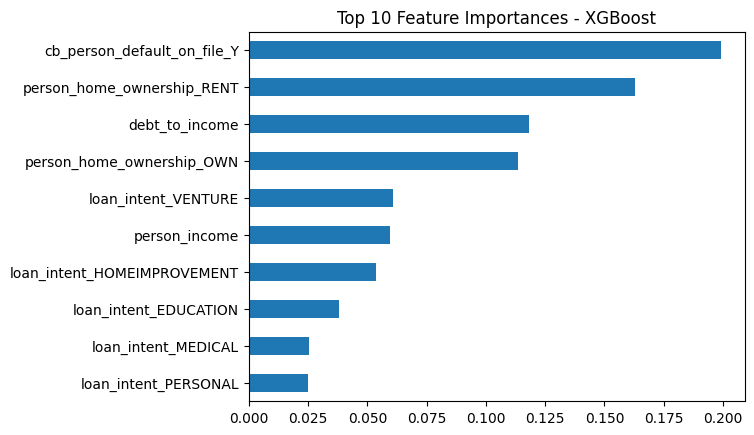

In [43]:
import matplotlib.pyplot as plt

feat_importance.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances - XGBoost")
plt.gca().invert_yaxis()
plt.show()

###  Feature Importance Analysis (XGBoost)

To understand the key drivers of credit risk, feature importance was extracted from the XGBoost model. The results highlight which variables most strongly influence the model’s predictions.

#### Top Features

1. **Previous Default History (`cb_person_default_on_file_Y`)**

   * The strongest predictor of default risk
   * Customers with a prior default are significantly more likely to default again
   * Aligns with real-world credit scoring practices

2. **Home Ownership Status (`person_home_ownership_RENT`, `OWN`)**

   * Renting is associated with higher default risk
   * Owning a home signals financial stability and lower risk

3. **Debt-to-Income Ratio (`debt_to_income`)**

   * Higher ratios indicate financial strain
   * Strong positive relationship with default probability

4. **Loan Intent (`loan_intent_*`)**

   * Certain loan purposes carry different risk levels
   * Venture and personal loans tend to be riskier compared to education or home improvement

5. **Income Level (`person_income`)**

   * Lower income borrowers are more likely to default
   * Reflects reduced repayment capacity



####  Key Insights

* **Behavioral history matters most**: Past defaults are the strongest signal of future risk
* **Financial stability indicators are critical**: Home ownership and income significantly impact risk
* **Loan purpose is not neutral**: Different borrowing motivations carry different risk profiles
* **Affordability drives outcomes**: Debt burden relative to income is a key determinant



####  Business Interpretation

These results align closely with traditional credit risk assessment frameworks:

* Prior defaults → High-risk flag
* High debt-to-income → Over-leveraged borrower
* Renting → Lower financial stability
* Low income → Reduced repayment ability

This alignment increases confidence in the model’s reliability and practical applicability in real-world lending decisions.


### SHAP Analysis

c:\Users\User\miniconda3\envs\wadhare\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


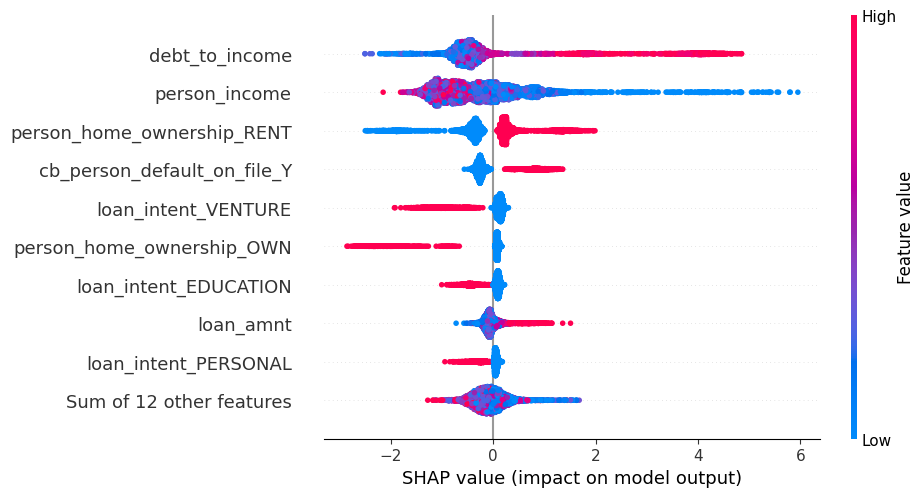

In [44]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

###  SHAP Analysis — Model Interpretability (XGBoost)

To enhance interpretability, SHAP (SHapley Additive exPlanations) was used to understand how each feature influences individual predictions.

####  Key Drivers of Default Risk

1. **Debt-to-Income Ratio (`debt_to_income`)**

   * Most influential feature overall
   * Higher values (red) strongly push predictions toward default
   * Clear indicator of financial strain

2. **Income (`person_income`)**

   * Higher income (red) reduces default risk
   * Lower income (blue) increases likelihood of default
   * Confirms repayment capacity as a key factor

3. **Home Ownership — RENT (`person_home_ownership_RENT`)**

   * Renting increases default probability
   * Strong positive SHAP contribution toward risk

4. **Previous Default (`cb_person_default_on_file_Y`)**

   * Prior default history significantly increases risk
   * One of the most consistent high-impact signals

5. **Loan Intent — Venture (`loan_intent_VENTURE`)**

   * Venture-related loans tend to increase default risk
   * Indicates higher uncertainty or speculative borrowing



####  Features That Reduce Risk

* **Home Ownership — OWN (`person_home_ownership_OWN`)**

  * Strong negative SHAP values → lowers default probability
  * Reflects financial stability

* **Education Loans (`loan_intent_EDUCATION`)**

  * Tend to reduce risk
  * Likely tied to long-term investment behavior



####  Key Insights

* **Affordability dominates risk**: Debt-to-income is the strongest predictor
* **Behavioral history matters**: Past defaults consistently signal future risk
* **Stability indicators are critical**: Income and home ownership shape outcomes
* **Loan purpose carries meaning**: Not all borrowing is equal



####  Business Interpretation

The SHAP analysis reinforces that the model aligns with real-world credit risk principles:

* High debt burden → increased default probability
* Low income → reduced repayment capacity
* Renting → lower financial stability
* Previous defaults → strong negative credit signal

This transparency increases trust in the model and supports its use in real-world lending decisions.


Deep learning was considered but not pursued due to the tabular nature of the dataset and the superior performance of tree-based ensemble methods.
